# NHL Time on Ice (TOI/GP): finding players worth a second look

This project builds an expected ice time model (`TOI/GP`) for NHL skaters, then uses the gap between **actual** and **predicted** minutes to flag players who may deserve reevaluation.

**Two goals**
1. **Reevaluation signals.** Some players play less than the model expects from their profile. Others play more. Those gaps are a starting point for deeper scouting, not a final verdict.
2. **Same metrics, different roles.** Identical looking stats can push expected TOI in different directions depending on position, usage history, and context. Understanding *why* the model treats two players differently helps with market search: you are matching role and goal, not only raw counting numbers.

**How to read residuals**
- `residual = actual TOI/GP − predicted TOI/GP`
- Positive: played more than the model expected (possible overplay relative to profile)
- Negative: played less than the model expected (possible underplay / untapped role)

The notebook ends with a player comparison using global feature importance and local SHAP contributions.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
from catboost import Pool

## Data

Player season stats were collected from:
- [NHL.com Stats](https://www.nhl.com/stats)
- [HockeyStats skater stats](https://hockeystats.com/stats)

Not every collected metric is used in the final model. Cleaning, joining seasons, and early prep were done primarily in **Power Query**. Player seasons were filtered to a minimum of **30 games** and **100 total TOI minutes** per season (also in Power Query) to reduce noise from tiny samples. This notebook focuses on feature engineering, modeling, and interpretation.

Files in `Data/`:
- `All Stats (Seasons 21-25).csv` — training history
- `For TOI-GP lag metric (Season 20-21) Github.csv` — prior season TOI for lag features
- `All Stats (Seasons 25-26).csv` — season used for prediction and residual review

**Target:** `TOI/GP` (minutes per game)


In [4]:
all = pd.read_csv(r"Data/All Stats (Seasons 21-25).csv")

all.head()

,Index,Season,S/C,Pos,G,A,A1,S,Ht,Wt,...,22+ MPH Speed Bursts,Top Speed (MPH),GF,GA,xGF,xGA,oiSh%,oiSv%,PDO,TOI/GP
0,146,21-22,R,D,6,29,10,135,78,228,...,4,22.48,81,76,61.28,68.59,11.36,91.02,102.38,23.56
1,872,22-23,L,L,5,7,4,66,75,209,...,0,21.87,21,13,23.70,19.73,9.21,94.69,103.90,9.11
2,146,22-23,R,D,4,23,6,133,78,228,...,3,22.80,50,73,56.53,68.97,7.66,90.74,98.39,23.00
3,872,23-24,L,L,6,6,3,57,75,209,...,0,21.79,14,22,16.73,18.24,6.64,90.91,97.54,8.83
4,71,21-22,R,D,10,44,25,203,77,228,...,0,21.83,68,65,63.05,70.14,9.43,92.26,101.69,26.15


In [5]:
all['Season'].value_counts()

Season
23-24    667
21-22    666
22-23    655
24-25    654
Name: count, dtype: int64

In [6]:
all.isna().sum()

Index                   0
Season                  0
S/C                     0
Pos                     0
G                       0
A                       0
A1                      0
S                       0
Ht                      0
Wt                      0
Hits                    0
HitsT                   0
BkS                     0
GvA                     0
TkA                     0
TOI                     0
GP                      0
SAT% Relative           0
Pen Drawn               0
Pen Taken               0
SAT%                    0
USAT %                  0
On-Ice GF %             0
OZ Ratio                0
OZ Start%               0
NZ Start%               0
DZ Start%               0
FOW                     0
FOL                     0
ixG                     0
iCF                     0
18+ MPH Speed Bursts    0
20+ MPH Speed Bursts    0
22+ MPH Speed Bursts    0
Top Speed (MPH)         0
GF                      0
GA                      0
xGF                     0
xGA         

In [7]:
all.groupby('Pos')['TOI/GP'].describe()

,count,mean,std,min,25%,50%,75%,max
Pos,,,,,,,,
C,839.0,15.253814,3.313372,7.72,12.5400,15.370,17.8950,22.81
D,906.0,19.140132,3.378192,7.82,16.5125,19.205,21.5675,26.75
L,487.0,14.752320,3.138136,4.83,12.3400,15.000,17.0100,22.47
R,410.0,15.016244,3.272998,6.40,12.4500,14.835,17.8550,22.91


In [8]:
all["Pos_group"] = all["Pos"].replace({"L": "W", "R": "W"})

all.head()


,Index,Season,S/C,Pos,G,A,A1,S,Ht,Wt,...,Top Speed (MPH),GF,GA,xGF,xGA,oiSh%,oiSv%,PDO,TOI/GP,Pos_group
0,146,21-22,R,D,6,29,10,135,78,228,...,22.48,81,76,61.28,68.59,11.36,91.02,102.38,23.56,D
1,872,22-23,L,L,5,7,4,66,75,209,...,21.87,21,13,23.70,19.73,9.21,94.69,103.90,9.11,W
2,146,22-23,R,D,4,23,6,133,78,228,...,22.80,50,73,56.53,68.97,7.66,90.74,98.39,23.00,D
3,872,23-24,L,L,6,6,3,57,75,209,...,21.79,14,22,16.73,18.24,6.64,90.91,97.54,8.83,W
4,71,21-22,R,D,10,44,25,203,77,228,...,21.83,68,65,63.05,70.14,9.43,92.26,101.69,26.15,D


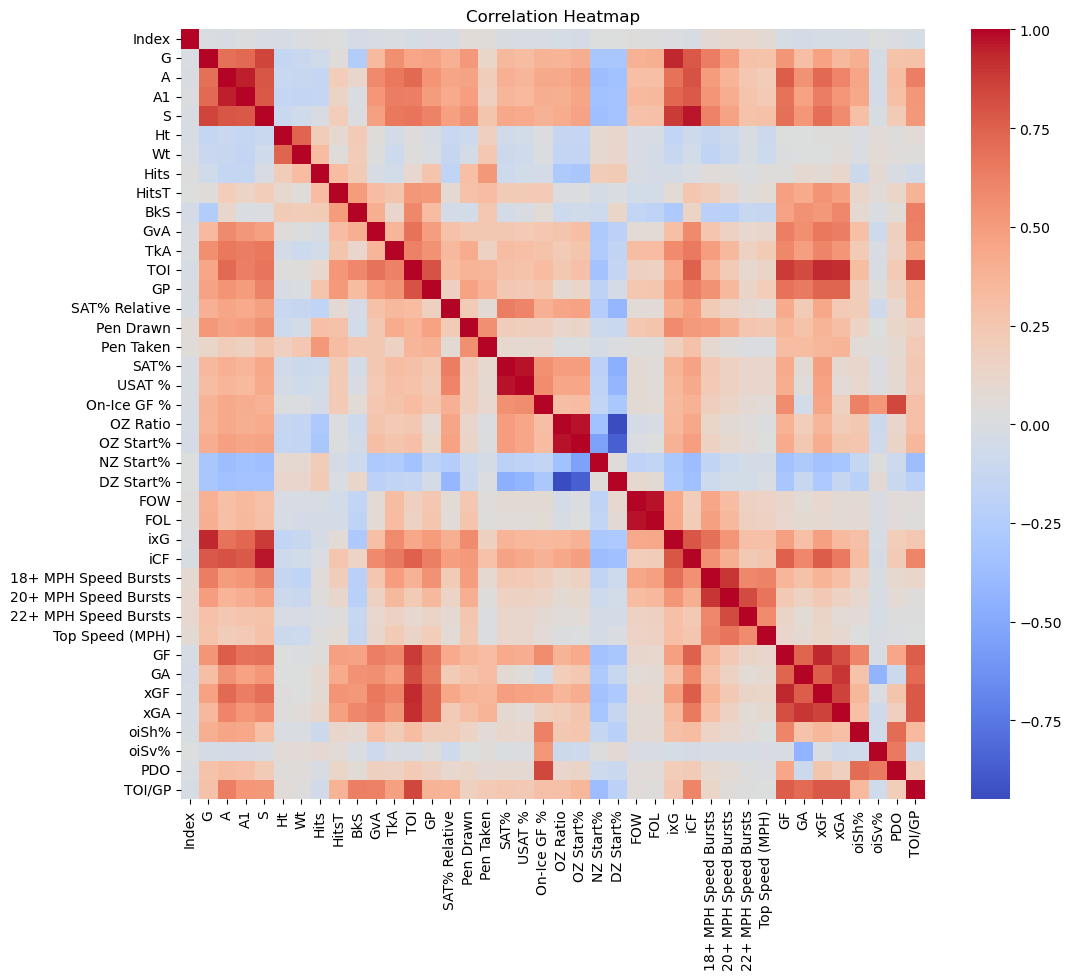

In [9]:
all_num = all.select_dtypes(include='number')  # keep only numeric columns

corr_matrix = all_num.corr() 
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [10]:
all.columns

Index(['Index', 'Season', 'S/C', 'Pos', 'G', 'A', 'A1', 'S', 'Ht', 'Wt',
       'Hits', 'HitsT', 'BkS', 'GvA', 'TkA', 'TOI', 'GP', 'SAT% Relative',
       'Pen Drawn', 'Pen Taken', 'SAT%', 'USAT %', 'On-Ice GF %', 'OZ Ratio',
       'OZ Start%', 'NZ Start%', 'DZ Start%', 'FOW', 'FOL', 'ixG', 'iCF',
       '18+ MPH Speed Bursts', '20+ MPH Speed Bursts', '22+ MPH Speed Bursts',
       'Top Speed (MPH)', 'GF', 'GA', 'xGF', 'xGA', 'oiSh%', 'oiSv%', 'PDO',
       'TOI/GP', 'Pos_group'],
      dtype='object')

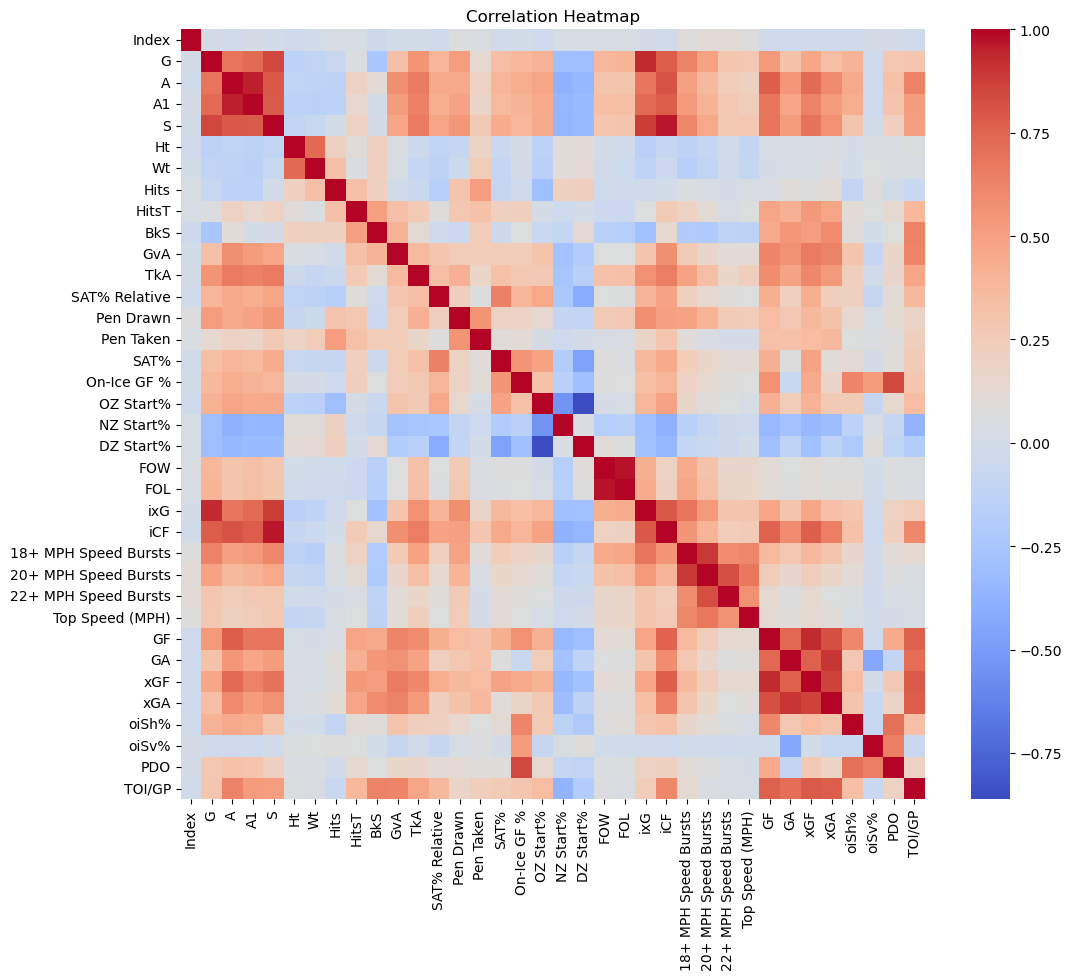

In [11]:
all2 = all[['Index', 'Season', 'S/C', 'Pos', 'G', 'A', 'A1', 'S', 'Ht', 'Wt',
       'Hits', 'HitsT', 'BkS', 'GvA', 'TkA', 'SAT% Relative',
       'Pen Drawn', 'Pen Taken', 'SAT%', 'On-Ice GF %',
       'OZ Start%', 'NZ Start%', 'DZ Start%', 'FOW', 'FOL', 'ixG', 'iCF',
       '18+ MPH Speed Bursts', '20+ MPH Speed Bursts', '22+ MPH Speed Bursts',
       'Top Speed (MPH)', 'GF', 'GA', 'xGF', 'xGA', 'oiSh%', 'oiSv%', 'PDO',
       'TOI/GP', 'Pos_group']]


all_num2 = all2.select_dtypes(include='number')  # keep only numeric columns

corr_matrix = all_num2.corr() 
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [12]:
toi20 = pd.read_csv(r"Data/For TOI-GP lag metric (Season 20-21) Github.csv")
toi20.head()

,Index,Player,Season,Team,S/C,Pos,GP,TOI,TOI/GP
0,744,Aaron Ekblad,20-21,FLA,R,D,35,878:11,25:05
1,156,Joe Pavelski,20-21,DAL,R,C,56,1065:14,19:01
2,21,Adam Boqvist,20-21,CHI,R,D,35,594:39,16:59
3,697,Brenden Dillon,20-21,WSH,L,D,56,1060:50,18:56
4,761,Adam Erne,20-21,DET,L,L,45,626:27,13:55


## Feature engineering

Build lag features and season ids for modeling.
Convert 20-21 TOI strings to minutes, then create:
- `Season id`
- `TOI/GP lag` (previous season ice time)
- `TOI_lag_missing` (1 if no prior season)


In [14]:
def parse_time_to_minutes(x):
    if isinstance(x, str) and ":" in x:
        m, s = x.split(":")
        return float(m) + float(s) / 60.0
    return float(x)
toi20["TOI/GP"] = toi20["TOI/GP"].apply(parse_time_to_minutes)

In [15]:
# --- 1) Encode season as a numeric id ---
# e.g. season "21-22" -> 1, "22-23" -> 2, ...
season_map = {"21-22": 1, "22-23": 2, "23-24": 3, "24-25": 4}
all2["Season id"] = all2["Season"].map(season_map)

# --- 2) Lag: previous season TOI/GP within all2 ---
all2 = all2.sort_values(["Index", "Season id"]).copy()
lag_raw = all2.groupby("Index")["TOI/GP"].shift(1)

# TOI map from 20-21
toi20_map = toi20.set_index("Index")["TOI/GP"]

# for 21-22, fill lag from 20-21 when available
mask_2122 = all2["Season id"] == 1  # 21-22
lag_raw.loc[mask_2122] = all2.loc[mask_2122, "Index"].map(toi20_map)

# flag: still missing after fill (player not in 20-21) -> 1
all2["TOI_lag_missing"] = lag_raw.isna().astype(int)

## placeholder fill for players with no lag

pos_col = "Pos_group"  # position group column

# mean TOI/GP by position across all2
mean_toi_by_pos = (
    all2.groupby(pos_col, dropna=False)["TOI/GP"].mean().round(2)
)
# map each row to its position mean
grp_mean_toi = all2[pos_col].map(mean_toi_by_pos)
all2["TOI/GP lag"] = lag_raw.fillna(grp_mean_toi)

C:\Users\User\AppData\Local\Temp\ipykernel_43100\3182582310.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all2["Season id"] = all2["Season"].map(season_map)


In [16]:
print(grp_mean_toi)
all2.groupby(['Season', 'TOI_lag_missing'])['TOI/GP lag'].count()

1772    19.14
537     14.87
538     14.87
2014    14.87
2435    14.87
        ...  
1810    14.87
1985    14.87
2241    14.87
2551    19.14
248     14.87
Name: Pos_group, Length: 2642, dtype: float64


Season  TOI_lag_missing
21-22   0                  497
        1                  169
22-23   0                  541
        1                  114
23-24   0                  583
        1                   84
24-25   0                  582
        1                   72
Name: TOI/GP lag, dtype: int64

## Model experiments (seasons 21-25)

Train/validation/test split to compare models.
Target: `TOI/GP`.

We try XGBoost, CatBoost, then an XGBoost + CatBoost ensemble, and check RMSE / R².


In [18]:
feature_cols = [
    'G', 'A', 'A1', 'S', 'Ht', 'Wt',
       'Hits', 'HitsT', 'BkS', 'GvA', 'TkA', 'SAT% Relative', 'Pen Drawn',
       'Pen Taken', 'SAT%', 'On-Ice GF %', 'OZ Start%', 'NZ Start%',
       'DZ Start%', 'FOW', 'FOL', 'ixG', 'iCF', '18+ MPH Speed Bursts',
       '20+ MPH Speed Bursts', '22+ MPH Speed Bursts', 'Top Speed (MPH)', 'GF',
       'GA', 'xGF', 'xGA', 'oiSh%', 'oiSv%', 'PDO', 'Pos_group',
       'Season id', 'TOI_lag_missing', 'TOI/GP lag'
]
X = all2[feature_cols]
y = all2['TOI/GP']

In [19]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=666
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=666
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (1690, 38)
Validation shape: (423, 38)
Test shape: (529, 38)


In [20]:
pos_train = pd.get_dummies(X_train["Pos_group"], prefix="Pos")
pos_cols = pos_train.columns.tolist()

def pos_onehot(X, cols):
    d = pd.get_dummies(X["Pos_group"], prefix="Pos")
    d = d.reindex(columns=cols, fill_value=0)
    X = X.drop(columns=["Pos_group"])
    return pd.concat([X, d], axis=1)
    
X_train = pos_onehot(X_train, pos_cols)
X_val = pos_onehot(X_val, pos_cols)
X_test = pos_onehot(X_test, pos_cols)

X_train.head()

,G,A,A1,S,Ht,Wt,Hits,HitsT,BkS,GvA,...,xGA,oiSh%,oiSv%,PDO,Season id,TOI_lag_missing,TOI/GP lag,Pos_C,Pos_D,Pos_W
84,28,47,25,246,74,205,112,74,32,24,...,38.81,9.36,92.44,101.81,3,0,18.760000,False,False,True
464,18,32,20,145,73,200,194,61,55,56,...,44.82,10.47,91.22,101.70,4,0,17.780000,True,False,False
1300,6,14,9,62,71,189,27,18,11,18,...,24.18,9.76,93.38,103.14,1,0,16.083333,False,False,True
2161,5,2,2,68,69,184,179,62,21,14,...,24.99,5.86,93.38,99.24,3,0,11.310000,False,False,True
708,3,13,6,76,76,208,94,62,75,29,...,46.16,11.67,89.42,101.08,1,0,18.400000,False,True,False


In [21]:
model = XGBRegressor(
    objective="reg:squarederror",
    random_state=666,
    n_estimators=5000,
    learning_rate=0.025, 
    max_depth=3, 
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2.0,
    gamma=0.3,
    n_jobs=-1,
    early_stopping_rounds=100,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

pred_train = model.predict(X_train)
rmse_train = mean_squared_error(y_train, pred_train, squared=False)

pred_val = model.predict(X_val)
rmse_val = mean_squared_error(y_val, pred_val, squared=False)

print("best_iteration:", model.best_iteration)
print("RMSE train:", rmse_train)
print("RMSE val:", rmse_val)



best_iteration: 636
RMSE train: 0.8997951977218681
RMSE val: 1.3172717885657665


In [22]:
imp = pd.Series(model.feature_importances_, index=X_val.columns).sort_values(ascending=False)
print(imp)

TOI/GP lag              0.306062
GF                      0.179165
xGA                     0.082953
Pos_D                   0.071301
A                       0.050379
xGF                     0.045219
BkS                     0.028644
GvA                     0.021975
GA                      0.020607
ixG                     0.018649
iCF                     0.012449
G                       0.011889
FOL                     0.009651
FOW                     0.008898
NZ Start%               0.008343
Hits                    0.007901
Pos_W                   0.007451
A1                      0.006973
TkA                     0.006703
TOI_lag_missing         0.006573
DZ Start%               0.006260
SAT% Relative           0.005919
S                       0.005808
Season id               0.005366
18+ MPH Speed Bursts    0.005322
22+ MPH Speed Bursts    0.004838
SAT%                    0.004800
Wt                      0.004582
Pen Taken               0.004462
Ht                      0.004323
Top Speed 

In [23]:

# ---------- 1) XGBoost baseline (all positions) ----------
model_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=666,
    n_estimators=5000,
    learning_rate=0.025,
    max_depth=3,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2.0,
    gamma=0.3,
    n_jobs=-1,
    early_stopping_rounds=100,
)
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
# ---------- 2) CatBoost ----------
model_cat = CatBoostRegressor(
    random_seed=666,
    loss_function="RMSE",
    iterations=5000,
    learning_rate=0.025,
    depth=6,
    l2_leaf_reg=5, 
    subsample=0.8,
    colsample_bylevel=0.8,
    verbose=0,
    early_stopping_rounds=100,
)
model_cat.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    verbose=False,
)
# ---------- 3) Ensemble weight on validation ----------
p_xgb_val = model_xgb.predict(X_val)
p_cat_val = model_cat.predict(X_val)
rmse_xgb_val = mean_squared_error(y_val, p_xgb_val, squared=False)
rmse_cat_val = mean_squared_error(y_val, p_cat_val, squared=False)
best_w, best_rmse_val = None, 1e9
for w in np.linspace(0, 1, 51):
    pred = w * p_xgb_val + (1 - w) * p_cat_val
    rmse = mean_squared_error(y_val, pred, squared=False)
    if rmse < best_rmse_val:
        best_rmse_val, best_w = rmse, w
        
print("RMSE val (XGB only):", rmse_xgb_val)
print("RMSE val (CatBoost only):", rmse_cat_val)
print("XGB weight (w):", round(best_w, 3))
print("RMSE val (ensemble):", best_rmse_val)

RMSE val (XGB only): 1.3172717885657665
RMSE val (CatBoost only): 1.293396451752685
XGB weight (w): 0.14
RMSE val (ensemble): 1.2927490790419127


In [24]:
pred_xgb_test = model_xgb.predict(X_test)
pred_cat_test = model_cat.predict(X_test)
pred_ens_test = best_w * pred_xgb_test + (1 - best_w) * pred_cat_test

rmse_xgb_test = mean_squared_error(y_test, pred_xgb_test, squared=False)
rmse_cat_test = mean_squared_error(y_test, pred_cat_test, squared=False)
rmse_ens_test = mean_squared_error(y_test, pred_ens_test, squared=False)

print("RMSE test — XGB:", rmse_xgb_test)
print("RMSE test — CatBoost:", rmse_cat_test) #Choose this model
print("RMSE test — ensemble:", rmse_ens_test)

RMSE test — XGB: 1.24609346523912
RMSE test — CatBoost: 1.2239941756927553
RMSE test — ensemble: 1.2227229978460552


In [25]:
r2_val = r2_score(y_val, model_cat.predict(X_val))
r2_test = r2_score(y_test, model_cat.predict(X_test))

print(r2_val)
print(r2_test)

0.8861102980817879
0.8897113935067034


## Final training setup

Rebuild features on the full historical table (`all2`).
This is the dataset used to train the final CatBoost model before predicting 25/26.


In [27]:
df_hist = all2.copy()

df_hist = df_hist.sort_values(["Index", "Season id"])

# raw lag before imputation
lag_raw = df_hist.groupby("Index")["TOI/GP"].shift(1)

# flag: missing previous season
df_hist["TOI_lag_missing"] = lag_raw.isna().astype(int)

# impute missing lag with mean TOI/GP by position (over df_hist)
pos_col = "Pos_group"
mean_toi_by_pos = df_hist.groupby(pos_col, dropna=False)["TOI/GP"].mean()
grp_mean_toi = df_hist[pos_col].map(mean_toi_by_pos)
df_hist["TOI/GP lag"] = lag_raw.fillna(grp_mean_toi)

# --- target encoding for S/C on full history ---
tmp = pd.DataFrame({
    "S/C": df_hist["S/C"].values,
    "y": df_hist["TOI/GP"].values,
})
means = tmp.groupby("S/C")["y"].mean()
global_mean = tmp["y"].mean()
df_hist["S_C_te"] = df_hist["S/C"].map(means).fillna(global_mean)

# --- base numeric columns (without Pos_group) ---
base_feature_cols = [
    'G', 'A', 'A1', 'S', 'Ht', 'Wt', 'Hits', 'HitsT', 'BkS', 'GvA', 'TkA',
       'SAT% Relative', 'Pen Drawn', 'Pen Taken', 'SAT%', 'On-Ice GF %',
       'OZ Start%', 'NZ Start%', 'DZ Start%', 'FOW', 'FOL', 'ixG', 'iCF',
       '18+ MPH Speed Bursts', '20+ MPH Speed Bursts', '22+ MPH Speed Bursts',
       'Top Speed (MPH)', 'GF', 'GA', 'xGF', 'xGA', 'oiSh%', 'oiSv%', 'PDO',
       'Season id', 'TOI_lag_missing', 'TOI/GP lag', 'S_C_te'
]
X_base = df_hist[base_feature_cols]

# --- one-hot Pos_group ---
pos_dummies = pd.get_dummies(df_hist["Pos_group"], prefix="Pos")
pos_cols = pos_dummies.columns.tolist()  # reuse later for 25/26

# final feature matrix X
X_final = pd.concat([X_base, pos_dummies], axis=1)

# dummies can be bool; cast to int
for c in pos_cols:
    X_final[c] = X_final[c].astype(int)
y = df_hist["TOI/GP"]

## Final CatBoost on full history

Train the production model on all seasons 21-25, then keep a small holdout for a sanity check.


In [29]:
X_final.columns

Index(['G', 'A', 'A1', 'S', 'Ht', 'Wt', 'Hits', 'HitsT', 'BkS', 'GvA', 'TkA',
       'SAT% Relative', 'Pen Drawn', 'Pen Taken', 'SAT%', 'On-Ice GF %',
       'OZ Start%', 'NZ Start%', 'DZ Start%', 'FOW', 'FOL', 'ixG', 'iCF',
       '18+ MPH Speed Bursts', '20+ MPH Speed Bursts', '22+ MPH Speed Bursts',
       'Top Speed (MPH)', 'GF', 'GA', 'xGF', 'xGA', 'oiSh%', 'oiSv%', 'PDO',
       'Season id', 'TOI_lag_missing', 'TOI/GP lag', 'S_C_te', 'Pos_C',
       'Pos_D', 'Pos_W'],
      dtype='object')

In [30]:
model_cat_final = CatBoostRegressor(
    random_seed=666,
    loss_function="RMSE",
    iterations=5000,
    learning_rate=0.025,
    depth=6,
    l2_leaf_reg=5,
    subsample=0.8,
    colsample_bylevel=0.8,
    verbose=0
)
model_cat_final.fit(X_final, y)

pred_train = model_cat_final.predict(X_final)
rmse_train = mean_squared_error(y, pred_train, squared=False)
r2_train = r2_score(y, pred_train)
print("RMSE (train):", rmse_train)
print("R² (train):", r2_train)


RMSE (train): 0.20308731932628574
R² (train): 0.9971842035322823


In [31]:
X_fit, X_val_final, y_fit, y_val_final = train_test_split(
    X_final, y, test_size=0.15, random_state=666
)

model_cat_tmp = CatBoostRegressor(
    random_seed=666,
    loss_function="RMSE",
    iterations=5000,
    learning_rate=0.025,
    depth=6,
    l2_leaf_reg=5,
    subsample=0.8,
    colsample_bylevel=0.8,
    verbose=0,
    early_stopping_rounds=100,
    use_best_model=True, 
)

model_cat_tmp.fit(X_fit, y_fit, eval_set=(X_val_final, y_val_final), verbose=100)
pred_val_final = model_cat_tmp.predict(X_val_final)

print("RMSE (val):", mean_squared_error(y_val_final, pred_val_final, squared=False))
print("R² (val):", r2_score(y_val_final, pred_val_final))

0:	learn: 3.7869386	test: 3.6467445	best: 3.6467445 (0)	total: 5.82ms	remaining: 29.1s
100:	learn: 1.5425190	test: 1.5111697	best: 1.5111697 (100)	total: 699ms	remaining: 33.9s
200:	learn: 1.3394614	test: 1.3656069	best: 1.3656069 (200)	total: 1.36s	remaining: 32.6s
300:	learn: 1.2433576	test: 1.3227144	best: 1.3227144 (300)	total: 2.01s	remaining: 31.4s
400:	learn: 1.1583088	test: 1.2949712	best: 1.2948299 (392)	total: 2.65s	remaining: 30.4s
500:	learn: 1.0834426	test: 1.2827829	best: 1.2827829 (500)	total: 3.3s	remaining: 29.7s
600:	learn: 1.0194050	test: 1.2727742	best: 1.2727742 (600)	total: 3.94s	remaining: 28.8s
700:	learn: 0.9671072	test: 1.2676995	best: 1.2675742 (696)	total: 4.59s	remaining: 28.1s
800:	learn: 0.9126497	test: 1.2622400	best: 1.2620517 (784)	total: 5.21s	remaining: 27.3s
900:	learn: 0.8667104	test: 1.2589933	best: 1.2589836 (894)	total: 5.83s	remaining: 26.5s
1000:	learn: 0.8258455	test: 1.2552615	best: 1.2552615 (1000)	total: 6.44s	remaining: 25.7s
1100:	learn:

In [32]:
best_iter = model_cat_tmp.get_best_iteration() 
best_iters = best_iter + 1

model_cat_final = CatBoostRegressor(
    random_seed=666,
    loss_function="RMSE",
    iterations=best_iters,
    learning_rate=0.025,
    depth=6,
    l2_leaf_reg=5,
    subsample=0.8,
    colsample_bylevel=0.8,
    verbose=0
)

model_cat_final.fit(X_final, y)

In [33]:
# train metric for final model
pred_train = model_cat_final.predict(X_final)
print("RMSE train:", mean_squared_error(y, pred_train, squared=False))
print("R2 train:", r2_score(y, pred_train))

# val metric for tmp model (if model_cat_tmp is already fit)
pred_val = model_cat_tmp.predict(X_val_final)
print("RMSE val:", mean_squared_error(y_val_final, pred_val, squared=False))
print("R2 val:", r2_score(y_val_final, pred_val))

print("best_iteration tmp:", model_cat_tmp.get_best_iteration())

RMSE train: 0.8075804679043228
R2 train: 0.9554746585385651
RMSE val: 1.2503296608835925
R2 val: 0.8858937976454099
best_iteration tmp: 1142


## Season 25/26 prediction

Load 25/26 stats, rebuild the same feature columns as in training, and predict `TOI/GP`.


In [35]:
all26 = pd.read_csv(r"Data/All Stats (Seasons 25-26).csv")


print(all26.columns)
all26.head()

Index(['Index', 'Season', 'S/C', 'Pos', 'GP', 'G', 'A', 'A1', 'S', 'Ht', 'Wt',
       'Hits', 'HitsT', 'BkS', 'GvA', 'TkA', 'TOI', 'SAT% Relative',
       'Pen Drawn', 'Pen Taken', 'SAT%', 'USAT %', 'On-Ice GF %', 'OZ Ratio',
       'OZ Start%', 'NZ Start%', 'DZ Start%', 'FOW', 'FOL', 'ixG', 'iCF',
       '18+ MPH Speed Bursts', '20+ MPH Speed Bursts', '22+ MPH Speed Bursts',
       'Top Speed (MPH)', 'GF', 'GA', 'xGF', 'xGA', 'oiSh%', 'oiSv%', 'PDO',
       'TOI/GP'],
      dtype='object')


,Index,Season,S/C,Pos,GP,G,A,A1,S,Ht,...,22+ MPH Speed Bursts,Top Speed (MPH),GF,GA,xGF,xGA,oiSh%,oiSv%,PDO,TOI/GP
0,1238,25-26,R,C,80,53,74,50,350,72,...,45,24.78,100,42,85.10,56.80,12.27,93.05,105.32,22.26
1,674,25-26,R,R,82,41,44,24,287,68,...,1,22.64,59,46,57.45,50.79,9.80,91.17,100.97,18.50
2,534,25-26,L,D,75,22,59,28,260,74,...,5,23.06,81,66,79.61,65.65,9.98,90.64,100.61,26.61
3,461,25-26,R,C,81,40,41,28,272,78,...,8,22.85,59,54,54.93,54.19,11.05,90.32,101.37,19.24
4,151,25-26,R,R,77,29,71,57,261,72,...,0,21.51,65,51,53.68,56.20,12.60,90.25,102.85,20.66


In [36]:
all26.groupby('Pos')['TOI/GP'].describe()

,count,mean,std,min,25%,50%,75%,max
Pos,,,,,,,,
C,218.0,15.119312,3.508123,6.75,12.4325,14.885,17.9325,22.99
D,224.0,19.186339,3.423942,10.04,16.8825,19.245,21.7125,27.74
L,113.0,14.758142,3.229862,8.55,12.3400,14.840,17.0500,22.15
R,105.0,15.282857,2.980890,7.81,13.3000,15.380,17.5500,20.66


In [37]:
all26.isna().sum()

Index                   0
Season                  0
S/C                     0
Pos                     0
GP                      0
G                       0
A                       0
A1                      0
S                       0
Ht                      0
Wt                      0
Hits                    0
HitsT                   0
BkS                     0
GvA                     0
TkA                     0
TOI                     0
SAT% Relative           0
Pen Drawn               0
Pen Taken               0
SAT%                    0
USAT %                  0
On-Ice GF %             0
OZ Ratio                0
OZ Start%               0
NZ Start%               0
DZ Start%               0
FOW                     0
FOL                     0
ixG                     0
iCF                     0
18+ MPH Speed Bursts    0
20+ MPH Speed Bursts    0
22+ MPH Speed Bursts    0
Top Speed (MPH)         0
GF                      0
GA                      0
xGF                     0
xGA         

In [38]:
df_2526 = all26.copy()

# 1) Pos_group: L/R -> W
df_2526["Pos_group"] = df_2526["Pos"].replace({"L": "W", "R": "W"})

# 2) Season id for 25/26 = next after max in history
df_2526["Season id"] = all2["Season id"].max() + 1

# 3) TOI lag + flag whether lag was imputed
hist_last = all2.sort_values("Season id").groupby("Index")["TOI/GP"].last()
toi_lag_raw = df_2526["Index"].map(hist_last)

mean_toi_by_pos = all2.groupby("Pos_group", dropna=False)["TOI/GP"].mean()
df_2526["TOI/GP lag"] = toi_lag_raw.fillna(df_2526["Pos_group"].map(mean_toi_by_pos))

df_2526["TOI_lag_missing"] = toi_lag_raw.isna().astype(int)

# 4) S_C_te from S/C means on history
sc_means = all2.groupby("S/C")["TOI/GP"].mean()
sc_global_mean = all2["TOI/GP"].mean()
df_2526["S_C_te"] = df_2526["S/C"].map(sc_means).fillna(sc_global_mean)

# 5) one-hot Pos_group (align to training pos_cols)
pos_dummies_2526 = pd.get_dummies(df_2526["Pos_group"], prefix="Pos")
pos_dummies_2526 = pos_dummies_2526.reindex(columns=pos_cols, fill_value=0).astype(int)

# 6) build X_2526
X_2526 = pd.concat([df_2526[base_feature_cols], pos_dummies_2526], axis=1)

# 7) ensure columns/order match training
X_2526 = X_2526.reindex(columns=X_final.columns, fill_value=0)

In [39]:
# 8) Predict
pred_2526 = model_cat_final.predict(X_2526)

# evaluate quality
rmse_2526 = mean_squared_error(df_2526["TOI/GP"], pred_2526, squared=False)
r2_2526 = r2_score(df_2526["TOI/GP"], pred_2526)
print("RMSE 25/26:", rmse_2526)
print("R2 25/26:", r2_2526)

RMSE 25/26: 1.1697217939621176
R2 25/26: 0.908847877081889


## Residuals, feature importance, and roles

After predicting 25/26 `TOI/GP`, compare actual vs expected ice time.

**Residuals** surface candidates for reevaluation (largest over/under vs the model).

**Global feature importance** answers: which features matter *on average* across the league for predicting TOI/GP? (For example, prior season ice time and on ice goal/xG context often rank high.)

**Local SHAP values** answer a different question: for *this specific player*, which features pushed the prediction up or down? Tree models do not have linear coefficients. SHAP contributions are the right way to explain one row.

That distinction matters for scouting. Two players can look similar on a few box score stats, yet the model expects different ice time because their roles differ (defense vs forward, lag TOI, zone starts, on ice rates, and so on). The comparison below shows how the same feature set can treat players differently.


In [41]:
# optional: players who over/under perform vs prediction
out = df_2526[["Index", "Pos", "TOI/GP", "TOI/GP lag", "TOI_lag_missing"]].copy()
out["pred_TOI/GP"] = pred_2526
out["residual"] = out["TOI/GP"] - out["pred_TOI/GP"]
out["abs_residual"] = out["residual"].abs()
print(out.sort_values("abs_residual", ascending=False).head(15))

     Index Pos  TOI/GP  TOI/GP lag  TOI_lag_missing  pred_TOI/GP  residual  \
608   1433   C    7.20   15.253814                1    11.296675 -4.096675   
289    193   D   22.71   22.060000                0    19.030646  3.679354   
637   1050   C   14.73   12.390000                0    11.108267  3.621733   
163    673   D   19.14   23.340000                0    22.605935 -3.465935   
554   1163   C    8.83   11.440000                0    12.087526 -3.257526   
426   1343   D   13.67   19.140132                1    16.861226 -3.191226   
30     222   D   22.69   17.300000                0    19.516733  3.173267   
570   1193   D   17.31   15.280000                0    14.268340  3.041660   
616    601   D   10.04   12.540000                0    13.032563 -2.992563   
564     10   C   16.51   14.320000                0    13.535806  2.974194   
490   1139   D   20.08   19.140132                1    17.112040  2.967960   
305   1058   C   12.51   15.253814                1    15.403239

In [42]:
top_over = out.sort_values("residual", ascending=False).head(20)
top_under = out.sort_values("residual", ascending=True).head(20)

print("TOP overplayed vs model:")
display(top_over)
print("TOP underplayed vs model:")
display(top_under)

TOP overplayed vs model:


,Index,Pos,TOI/GP,TOI/GP lag,TOI_lag_missing,pred_TOI/GP,residual,abs_residual
289,193,D,22.71,22.060000,0,19.030646,3.679354,3.679354
637,1050,C,14.73,12.390000,0,11.108267,3.621733,3.621733
30,222,D,22.69,17.300000,0,19.516733,3.173267,3.173267
570,1193,D,17.31,15.280000,0,14.268340,3.041660,3.041660
564,10,C,16.51,14.320000,0,13.535806,2.974194,2.974194
490,1139,D,20.08,19.140132,1,17.112040,2.967960,2.967960
504,369,D,21.31,21.570000,0,18.574063,2.735937,2.735937
178,1219,C,19.15,16.710000,0,16.503850,2.646150,2.646150
382,851,C,14.77,11.660000,0,12.137408,2.632592,2.632592
580,681,C,14.19,11.800000,0,11.597413,2.592587,2.592587


TOP underplayed vs model:


,Index,Pos,TOI/GP,TOI/GP lag,TOI_lag_missing,pred_TOI/GP,residual,abs_residual
608,1433,C,7.20,15.253814,1,11.296675,-4.096675,4.096675
163,673,D,19.14,23.340000,0,22.605935,-3.465935,3.465935
554,1163,C,8.83,11.440000,0,12.087526,-3.257526,3.257526
426,1343,D,13.67,19.140132,1,16.861226,-3.191226,3.191226
616,601,D,10.04,12.540000,0,13.032563,-2.992563,2.992563
305,1058,C,12.51,15.253814,1,15.403239,-2.893239,2.893239
645,62,D,10.86,14.390000,0,13.655771,-2.795771,2.795771
150,745,D,20.59,22.200000,0,23.228439,-2.638439,2.638439
557,1131,C,9.68,14.690000,0,12.289268,-2.609268,2.609268
647,1319,D,10.97,19.140132,1,13.538799,-2.568799,2.568799


In [43]:
imp = pd.Series(
    model_cat_final.get_feature_importance(),
    index=X_final.columns
).sort_values(ascending=False)
print(imp.head(20))

TOI/GP lag              21.590858
Pos_D                   10.220370
A                        7.138814
GF                       6.153933
xGF                      6.043841
xGA                      5.596941
BkS                      5.325384
ixG                      3.068111
G                        2.262291
iCF                      2.231333
FOL                      2.141139
S                        2.002360
GvA                      1.895922
SAT% Relative            1.774673
GA                       1.706442
Season id                1.626876
18+ MPH Speed Bursts     1.602660
TkA                      1.527899
A1                       1.518884
HitsT                    1.467725
dtype: float64


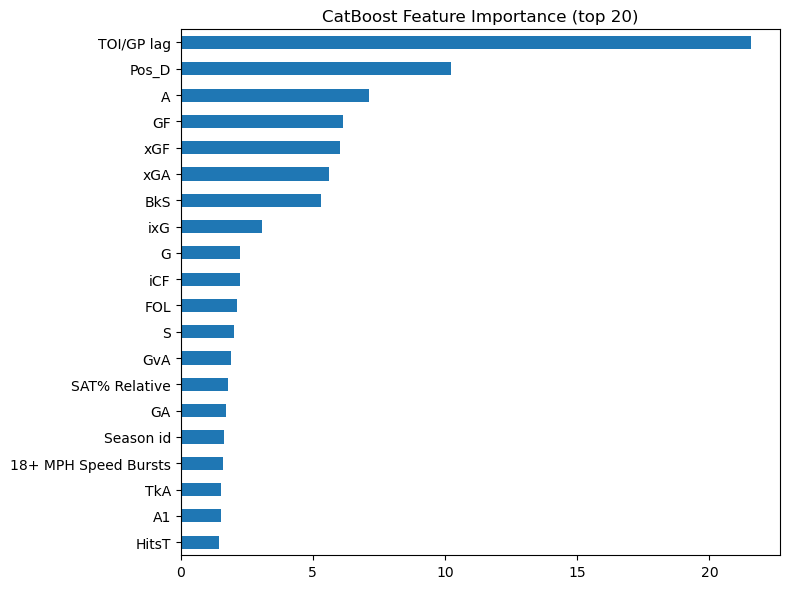

In [44]:
top20 = imp.head(20).iloc[::-1]  # reverse for nicer bar chart
plt.figure(figsize=(8, 6))
top20.plot(kind="barh")
plt.title("CatBoost Feature Importance (top 20)")
plt.tight_layout()
plt.show()


## Player comparison (SHAP)

Compare **Player_A** (Index 1433) and **Player_B** (Index 851) on the same feature set.

| | Player_A | Player_B |
|---|---|---|
| Actual TOI/GP | ~7.2 | ~14.8 |
| Predicted TOI/GP | ~11.3 | ~12.1 |
| Residual | negative (underplayed vs model) | positive (overplayed vs model) |

For each player we show:
1. Actual `TOI/GP`, predicted `TOI/GP`, and residual
2. Top SHAP contributions that raised or lowered the prediction
3. Where the two players diverge most (feature contribution differences)

SHAP values are local contributions for that row, not linear regression coefficients.


In [46]:
# 1) residuals
out = df_2526[["Index", "Pos", "TOI/GP"]].copy()
out["pred_TOI/GP"] = pred_2526
out["residual"] = out["TOI/GP"] - out["pred_TOI/GP"]
out["abs_residual"] = out["residual"].abs()
idx_player_a = 1433  # Player_A
idx_player_b = 851  # Player_B
row_b = out[out["Index"] == idx_player_a].iloc[0]
row_o = out[out["Index"] == idx_player_b].iloc[0]
print("Player_A:", row_b.to_dict())
print("Player_B:", row_o.to_dict())

# 2) X_2526 rows for these players
mask_b = df_2526["Index"] == idx_player_a
mask_o = df_2526["Index"] == idx_player_b
i_b = df_2526.index[mask_b][0]
i_o = df_2526.index[mask_o][0]
X_b = X_2526.loc[[i_b]]
X_o = X_2526.loc[[i_o]]

# 3) SHAP (CatBoost needs Pool)
feature_names = X_2526.columns.tolist()
pool_b = Pool(X_b, feature_names=feature_names)
pool_o = Pool(X_o, feature_names=feature_names)
shap_b = model_cat_final.get_feature_importance(pool_b, type="ShapValues")
shap_o = model_cat_final.get_feature_importance(pool_o, type="ShapValues")

# shap returns (1, n_features+1); squeeze to (n_features+1)
if isinstance(shap_b, np.ndarray) and shap_b.ndim == 2:
    shap_b = shap_b[0]
    shap_o = shap_o[0]
    
# last element is baseline
contrib_b = shap_b[:-1]
contrib_o = shap_o[:-1]
shap_df_b = pd.DataFrame({"feature": feature_names, "shap": contrib_b})
print("\nTop POSITIVE contributors for Player_A (push up prediction):")
display(shap_df_b.sort_values("shap", ascending=False).head(15))
print("\nTop NEGATIVE contributors for Player_A (push down prediction):")
display(shap_df_b.sort_values("shap", ascending=True).head(15))
shap_df = pd.DataFrame({
    "feature": feature_names,
    "shap_player_a": contrib_b,
    "shap_player_b": contrib_o
})

shap_df["diff_b_minus_a"] = shap_df["shap_player_b"] - shap_df["shap_player_a"]
shap_df["abs_diff"] = shap_df["diff_b_minus_a"].abs()
top_diff = shap_df.sort_values("abs_diff", ascending=False).head(15)
print("\nFeatures that most differentiate Player_B vs Player_A:")
print(top_diff[["feature", "shap_player_a", "shap_player_b", "diff_b_minus_a"]])


Player_A: {'Index': 1433, 'Pos': 'C', 'TOI/GP': 7.2, 'pred_TOI/GP': 11.296675404117696, 'residual': -4.096675404117696, 'abs_residual': 4.096675404117696}
Player_B: {'Index': 851, 'Pos': 'C', 'TOI/GP': 14.77, 'pred_TOI/GP': 12.137407811010497, 'residual': 2.632592188989502, 'abs_residual': 2.632592188989502}

Top POSITIVE contributors for Player_A (push up prediction):


,feature,shap
23,18+ MPH Speed Bursts,0.154241
6,Hits,0.073946
15,On-Ice GF %,0.060898
13,Pen Taken,0.056798
17,NZ Start%,0.054119
7,HitsT,0.046004
31,oiSh%,0.038312
24,20+ MPH Speed Bursts,0.029234
26,Top Speed (MPH),0.028301
25,22+ MPH Speed Bursts,0.024871



Top NEGATIVE contributors for Player_A (push down prediction):


,feature,shap
36,TOI/GP lag,-0.756913
1,A,-0.693223
39,Pos_D,-0.605613
8,BkS,-0.597118
30,xGA,-0.401733
21,ixG,-0.360308
0,G,-0.338776
28,GA,-0.297655
14,SAT%,-0.257202
27,GF,-0.242601



Features that most differentiate Player_B vs Player_A:
                 feature  shap_player_a  shap_player_b  diff_b_minus_a
36            TOI/GP lag      -0.756913      -1.576594       -0.819681
8                    BkS      -0.597118       0.033402        0.630520
21                   ixG      -0.360308       0.070765        0.431072
6                   Hits       0.073946      -0.214562       -0.288508
23  18+ MPH Speed Bursts       0.154241      -0.120951       -0.275191
35       TOI_lag_missing      -0.196389       0.047495        0.243884
14                  SAT%      -0.257202      -0.016392        0.240810
17             NZ Start%       0.054119      -0.175026       -0.229145
11         SAT% Relative      -0.073259      -0.293633       -0.220374
1                      A      -0.693223      -0.495426        0.197797
0                      G      -0.338776      -0.144065        0.194711
39                 Pos_D      -0.605613      -0.451572        0.154041
28                   


## Why SHAP treats Player_A and Player_B differently

SHAP differs because the **feature values differ**, so the trees send each player down different paths. Same metric names, different roles and context.

**Player_A (underplayed vs model)**  
Actual ice time is well below prediction. Positive SHAP from intensity style features (speed bursts, hits) suggests a proactive profile even on short minutes. Negative SHAP from counting / volume context (assists, goals, ixG, blocks, TOI lag, and a missing prior season lag) keeps the expectation from looking like a top line workload. Still, predicted TOI stays clearly above actual: a candidate to reevaluate **upward** on usage.

**Player_B (overplayed vs model)**  
Many box score numbers look stronger in absolute terms, but the model only expects roughly mid teens minutes from that full profile. Actual TOI sits above prediction: a candidate to reevaluate the **other** way (more ice than the feature profile usually implies), not necessarily "better than peers at the same ice time" in a value sense.

**Scouting takeaway**  
Use the residual as a mismatch flag and SHAP as the role story. Film and context (coach, PP/PK, injuries, linemates) still come next.


## Takeaways

1. A TOI/GP model is useful less as a crystal ball and more as a **mismatch detector**: who plays more or less than their profile usually implies.
2. Global importance shows the league wide drivers of ice time. SHAP shows why *this* player expectation moved.
3. The Player_A vs Player_B comparison is the practical example: same feature set, different SHAP signs and magnitudes, different residual story (underplayed vs overplayed). That role signal is what you want when searching the market.
4. The same actual vs expected outputs were loaded into a **Power BI** dashboard for season 25/26: all skaters, actual vs predicted TOI/GP, with underplayed and overplayed players clearly separated in the model/stats context. (Dashboard file not in this repo.)

**Limitations**
- Same season counting stats help explain current ice time given the season profile. This is not a pure prior year only forecast.
- Large residuals need film / context (injury, coach preference, PP/PK, linemates) before any roster decision.
- Target encoding for shot side (S/C) was fit on the full final training history; stricter CV would fit encoding inside each fold.
